In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib_inline import backend_inline
backend_inline.set_matplotlib_formats('svg')

import numpy as np

In [17]:
train_transform = transforms.Compose([#本次无用，此用于训练中数据增强
    transforms.RandomCrop(32, padding=2),  # 先padding到36x36，再随机裁剪回32x32
    transforms.RandomHorizontalFlip(p=0.5),  # 50%概率水平翻转
    transforms.ColorJitter(
    brightness=0.1,  # 亮度随机变换范围
    contrast=0.1,    # 对比度
    saturation=0.1,  # 饱和度
    hue=0            # 色调（不调整）
),
    transforms.ToTensor(),
    # CIFAR-10专用均值和方差（必须用对应数据集的统计值）
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

In [18]:
# 2. 加载数据集
train_dataset = datasets.CIFAR10(root="C:/Jupyter(Anaconda)/data", train=True, download=False)
test_dataset = datasets.CIFAR10(root="C:/Jupyter(Anaconda)/data", train=False, download=False)

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [20]:
# ========== 2. 数据增强：在 CPU 上对 numpy 数组批量操作 ==========
# 增强操作：水平翻转 + 随机裁剪（每张原图生成 N_AUG 份增强图）
N_AUG = 1   # 每张原图增强次数，最终训练集 = 原图 × (1 + N_AUG)

aug_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5), # 随机水平翻转
    transforms.RandomCrop(32, padding=2),   # 随机裁剪
    transforms.ColorJitter(brightness=0.1,  # 颜色抖动
                           contrast=0.1,
                           saturation=0.1),
    transforms.ToTensor(),                  # 输出 [0,1] float tensor (C,H,W)
])

def apply_augmentation(imgs_np, n_aug=1):#先扩增数据集，之后一起训练
    """
    imgs_np: (N, 32, 32, 3) uint8 numpy
    返回: (N*(1+n_aug), 3, 32, 32) float32 CPU Tensor，值域 [0,1]
    原图（转 tensor）在前，增强图在后
    """
    N = len(imgs_np)
    # 原图直接转 tensor：(N, 3, 32, 32)，归一化到 [0,1]
    originals = torch.from_numpy(imgs_np).permute(0, 3, 1, 2).float().div_(255.0)

    aug_list = [originals]
    for _ in range(n_aug):
        aug_batch = torch.stack([aug_transform(imgs_np[i]) for i in range(N)])
        aug_list.append(aug_batch)             # 每次生成 (N, 3, 32, 32)

    return torch.cat(aug_list, dim=0)          # (N*(1+n_aug), 3, 32, 32)

print("正在进行数据增强...")
train_imgs_aug = apply_augmentation(train_dataset.data, n_aug=N_AUG)   # (N*(1+N_AUG), 3, 32, 32)
y_train = torch.tensor(
    train_dataset.targets * (1 + N_AUG)          # 标签同步扩充：[原图标签, 增强1标签, ...]
)
print(f"增强后训练集大小: {train_imgs_aug.shape[0]} 张")

正在进行数据增强...
增强后训练集大小: 100000 张


In [21]:
#加载模型并移至 GPU
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_model.fc = nn.Identity()  # 移除全连接层
resnet_model = resnet_model.to(device)
resnet_model.eval()

#冻结特征提取器的参数
for param in resnet_model.parameters():
    param.requires_grad = False

In [22]:
#定义归一化参数
resnet_mean = [0.485, 0.456, 0.406]
resnet_std  = [0.229, 0.224, 0.225]

@torch.no_grad()
def fast_extract(imgs_tensor, batch_size=1024):#specially for augment
    """
    imgs_tensor: (N, 3, 32, 32) float32 CPU Tensor，值域 [0,1]
    返回: (N, 512) float32 CPU Tensor
    """
    resnet_model.eval()

    mean = torch.tensor(resnet_mean).view(1, 3, 1, 1).to(device)
    std  = torch.tensor(resnet_std).view(1, 3, 1, 1).to(device)

    N = imgs_tensor.shape[0]
    all_features = torch.zeros(N, 512, dtype=torch.float32)

    for i in range(0, N, batch_size):
        batch = imgs_tensor[i:i + batch_size].to(device)
        batch = F.interpolate(batch, size=(224, 224),
                              mode='bilinear', align_corners=False)
        batch.sub_(mean).div_(std)

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            feat = resnet_model(batch)

        all_features[i:i + batch_size] = feat.float().cpu()

    return all_features

In [23]:
print("正在提取训练集特征（含增强）...")
X_train = fast_extract(train_imgs_aug,batch_size=1024)         # (N*(1+N_AUG), 512)

# 测试集：直接从原始 numpy 转 tensor，不做增强
test_imgs = torch.from_numpy(test_dataset.data).permute(0, 3, 1, 2).float().div_(255.0)#train在extract中做了标准化，test在这完成

print("正在提取测试集特征...")
X_test = fast_extract(test_imgs)               # (10000, 512)
y_test = torch.tensor(test_dataset.targets)


print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

正在提取训练集特征（含增强）...
正在提取测试集特征...
X_train: torch.Size([100000, 512]), X_test: torch.Size([10000, 512])


In [24]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=250,
    shuffle=True,
    drop_last=True,                 # 丢弃最后不足 batch_size 的样本
    pin_memory=(device.type == "cuda")
)

test2_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=500,
    shuffle=False,
    pin_memory=(device.type == "cuda")
)

In [25]:
class TrainModel(nn.Module):
    def __init__(self):
        super (TrainModel,self).__init__()
        self.net=nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),    # 加入 BN 层提高稳定性
            nn.ReLU(),
            nn.Dropout(0.2),        # 防止过拟合
            nn.Linear(512, 10)
        )
    def forward(self,X):
        y=self.net(X)
        return y   #输出

In [26]:
Model=TrainModel().to('cuda')
Model

TrainModel(
  (net): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [27]:
%run MulClassSVM.ipynb
loss_fn1=MultiClassSVM()#自己写的loss
loss_fn2=nn.CrossEntropyLoss()

In [28]:
learning_rate=0.0001
optimizer=torch.optim.Adam(
    Model.parameters(),
    lr=learning_rate,
    weight_decay=0.0001
)
# 余弦退火调度器：随 epoch 平滑降低学习率
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)

Epoch [01/22]  Train Acc: 78.2270%  lr: 9.96e-05
Epoch [02/22]  Train Acc: 85.8520%  lr: 9.84e-05
Epoch [03/22]  Train Acc: 87.4000%  lr: 9.65e-05
Epoch [04/22]  Train Acc: 88.1670%  lr: 9.38e-05
Epoch [05/22]  Train Acc: 88.9120%  lr: 9.05e-05
Epoch [06/22]  Train Acc: 89.4480%  lr: 8.64e-05
Epoch [07/22]  Train Acc: 89.9890%  lr: 8.19e-05
Epoch [08/22]  Train Acc: 90.3940%  lr: 7.68e-05
Epoch [09/22]  Train Acc: 90.8920%  lr: 7.13e-05
Epoch [10/22]  Train Acc: 91.2410%  lr: 6.55e-05
Epoch [11/22]  Train Acc: 91.5590%  lr: 5.94e-05
Epoch [12/22]  Train Acc: 91.9780%  lr: 5.31e-05
Epoch [13/22]  Train Acc: 92.2480%  lr: 4.69e-05
Epoch [14/22]  Train Acc: 92.5710%  lr: 4.06e-05
Epoch [15/22]  Train Acc: 92.7520%  lr: 3.45e-05
Epoch [16/22]  Train Acc: 93.0200%  lr: 2.87e-05
Epoch [17/22]  Train Acc: 93.1590%  lr: 2.32e-05
Epoch [18/22]  Train Acc: 93.2760%  lr: 1.81e-05
Epoch [19/22]  Train Acc: 93.5040%  lr: 1.36e-05
Epoch [20/22]  Train Acc: 93.5540%  lr: 9.55e-06
Epoch [21/22]  Train

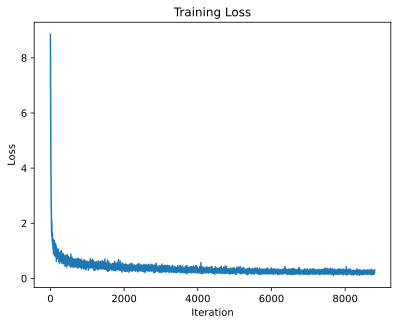

In [29]:
#训练网络
epochs=22
losses=[]
for epoch in range(epochs):
    Model.train() #训练模式
    correct,total=0,0
    for (x,y) in train_loader:#获取小批次x,y
        x,y=x.to(device),y.to(device)

        Pred=Model(x)#一次前向传播
        loss=0.85*loss_fn1(Pred,y)+0.15*loss_fn2(Pred,y)#计算损失函数
        losses.append(loss.item())
        optimizer.zero_grad()#清理上一轮滞留的梯度
        loss.backward()#一次反向传播
        optimizer.step()#优化内部参数
        correct    += (Pred.argmax(dim=1) == y).sum().item()
        total      += y.size(0)

    scheduler.step()
    train_acc  = correct    / total

    print(f"Epoch [{epoch+1:02d}/{epochs}]  "
          f"Train Acc: {100*train_acc:.4f}%  "
          f"lr: {scheduler.get_last_lr()[0]:.2e}")


# 绘制损失曲线
Fig = plt.figure()
plt.plot(range(len(losses)), losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [ ]:
def evaluate(loader):
    """返回在给定 loader 上的准确率"""
    Model.eval()
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = Model(X_batch).argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total   += y_batch.size(0)
    return correct / total

print("正在评估测试集...")#89.09% 22epochs
print(f"测试集准确率：{evaluate(test2_loader)*100:.4f}%")

正在评估测试集...
测试集准确率：89.0900%


In [31]:
torch.save(Model.state_dict(), "best_Conv+MLP.pth")